In [1]:
!pip install torch-geometric -q

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_dense_adj
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

print("PyTorch version:", torch.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.0 MB/s eta 0:00:00
PyTorch version: 2.10.0+cpu


# **Cora dataset**
- Benchmark citation network for GNNs

In [2]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')

#Single graph object
data    = dataset[0]

print("Dataset info: ")
print(f"Number of graphs   : {len(dataset)}")
print(f"Number of classes  : {dataset.num_classes}")
print(f"Number of features : {dataset.num_node_features}")

print("Graph info:")
print(f"Nodes              : {data.num_nodes}")
print(f"Edges              : {data.num_edges}")
print(f"Node feature shape : {data.x.shape}")
print(f"Edge index shape   : {data.edge_index.shape}")
print(f"Labels shape       : {data.y.shape}")

Processing...


Dataset info: 
Number of graphs   : 1
Number of classes  : 7
Number of features : 1433
Graph info:
Nodes              : 2708
Edges              : 10556
Node feature shape : torch.Size([2708, 1433])
Edge index shape   : torch.Size([2, 10556])
Labels shape       : torch.Size([2708])


Done!


## **Edge_index**


In [3]:
# edge_index is shape [2, num_edges]
# row 0 = source nodes, row 1 = destination nodes
# each column is one directed edge

print("First 8 edges (as source → dest pairs):")
for i in range(8):
    src  = data.edge_index[0, i].item()
    dest = data.edge_index[1, i].item()
    print(f"  edge {i}: node {src:4d} → node {dest:4d}")

print(f"\nIs undirected: {data.is_undirected()}")
print(f"Actual unique edges: {data.num_edges // 2}")


First 8 edges (as source → dest pairs):
  edge 0: node  633 → node    0
  edge 1: node 1862 → node    0
  edge 2: node 2582 → node    0
  edge 3: node    2 → node    1
  edge 4: node  652 → node    1
  edge 5: node  654 → node    1
  edge 6: node    1 → node    2
  edge 7: node  332 → node    2

Is undirected: True
Actual unique edges: 5278


## **Node Features**

*   Each node = one paper
*   Each feature = whether a specific word appears in that paper (bag of words)



In [4]:

print("Node feature matrix x:")
print(f"  Shape  : {data.x.shape}  → [num_nodes, num_features]")
print(f"  Dtype  : {data.x.dtype}")
print(f"  Min    : {data.x.min().item():.1f}")
print(f"  Max    : {data.x.max().item():.1f}")
sparsity = (1 - data.x.mean()).item()
print(f"  Feature sparsity: {sparsity:.1%}")
print("\nFeatures of node 0 (first 20 values):")
print(" ", data.x[0, :20].tolist())

Node feature matrix x:
  Shape  : torch.Size([2708, 1433])  → [num_nodes, num_features]
  Dtype  : torch.float32
  Min    : 0.0
  Max    : 1.0
  Feature sparsity: 98.7%

Features of node 0 (first 20 values):
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]


# **Understanding labels and splits**

In [5]:
print("Label distribution across 7 classes:")
for c in range(dataset.num_classes):
    count = (data.y == c).sum().item()
    bar   = "█" * (count // 10)
    print(f"  Class {c}: {count:4d} nodes  {bar}")

print(f"\nTrain nodes : {data.train_mask.sum().item()}")
print(f"Val nodes   : {data.val_mask.sum().item()}")
print(f"Test nodes  : {data.test_mask.sum().item()}")
print(f"Unlabeled   : {data.num_nodes - data.train_mask.sum().item() - data.val_mask.sum().item() - data.test_mask.sum().item()}")

Label distribution across 7 classes:
  Class 0:  351 nodes  ███████████████████████████████████
  Class 1:  217 nodes  █████████████████████
  Class 2:  418 nodes  █████████████████████████████████████████
  Class 3:  818 nodes  █████████████████████████████████████████████████████████████████████████████████
  Class 4:  426 nodes  ██████████████████████████████████████████
  Class 5:  298 nodes  █████████████████████████████
  Class 6:  180 nodes  ██████████████████

Train nodes : 140
Val nodes   : 500
Test nodes  : 1000
Unlabeled   : 1068


#  **Visualize a subgraph**

/tmp/ipykernel_18277/1873069215.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


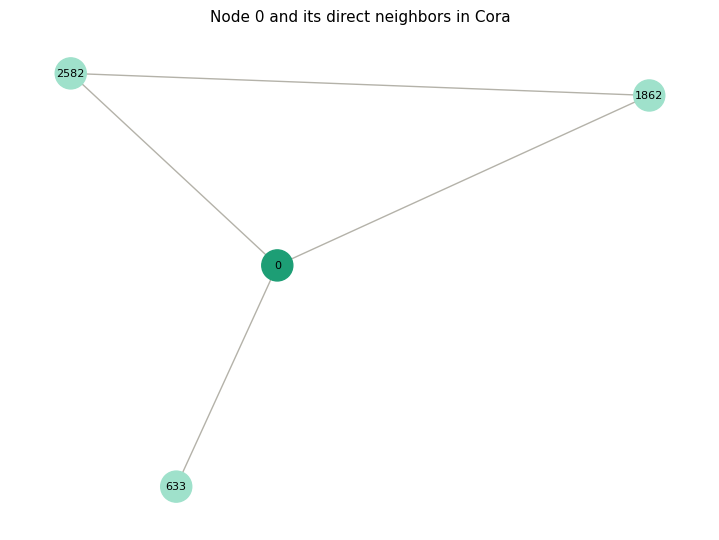

Node 0 has 3 neighbors


In [6]:
G        = to_networkx(data, to_undirected=True)
node_ids = [0] + list(G.neighbors(0))
subgraph  = G.subgraph(node_ids)

colors = ['#1D9E75' if n == 0 else '#9FE1CB' for n in subgraph.nodes()]

plt.figure(figsize=(7, 5))
nx.draw(subgraph, node_color=colors, with_labels=True,
        node_size=500, font_size=8, edge_color='#B4B2A9')
plt.title("Node 0 and its direct neighbors in Cora", fontsize=11)
plt.tight_layout()
plt.show()
print(f"Node 0 has {G.degree(0)} neighbors")
